The bad result is:
{}


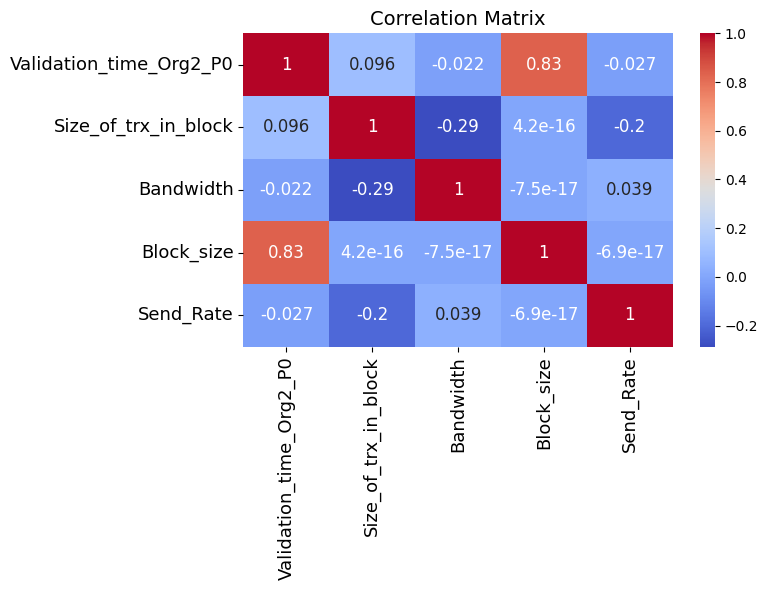

Correlation with 'Validation_time_Org2_P0':
Validation_time_Org2_P0    1.000000
Block_size                 0.834613
latancy                    0.756338
Size_of_trx_in_block       0.095956
Bandwidth                 -0.022315
Send_Rate                 -0.026764
throuout                  -0.781110
Name: Validation_time_Org2_P0, dtype: float64

Feature Importances (impurity-based, fitted on train only):
            Feature  Importance
2        Block_size    0.979589
0  Transaction_Size    0.009820
3         Send_Rate    0.006879
1         Bandwidth    0.003712


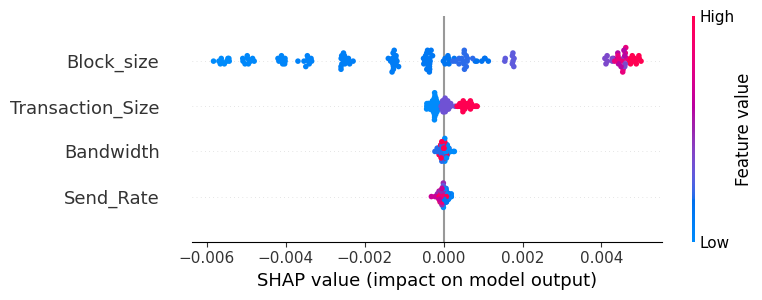

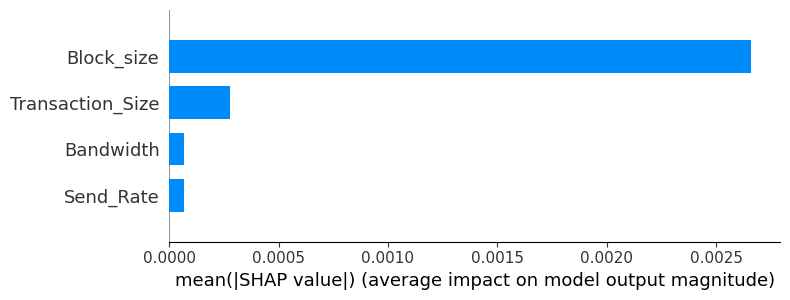


SHAP Feature Importances:
            Feature  mean_|SHAP|
2        Block_size     0.002660
0  Transaction_Size     0.000278
1         Bandwidth     0.000066
3         Send_Rate     0.000065

Top 2 Features (by SHAP):
['Block_size', 'Transaction_Size']


KeyError: "['Transaction_Size'] not in index"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                                8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                          1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                    5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Validation_time_Org2_P0": [
0.001513752,
0.002034686,
0.002755229,
0.003597687,
0.003994092,
0.005400763,
0.006161652,
0.00730135,
0.008488258,
0.007511476,
0.008229439,
0.010950977,
0.011365286,
0.011072794,
0.01232779,
0.002029182,
0.00287522,
0.003320569,
0.004168946,
0.005746053,
0.006952802,
0.007610684,
0.008276953,
0.009235258,
0.008883526,
0.009176614,
0.010762534,
0.010897866,
0.010730251,
0.010728839,
0.001368164,
0.002094546,
0.002778375,
0.003595652,
0.004341723,
0.005879693,
0.006462546,
0.006649107,
0.008510135,
0.006760271,
0.00851545,
0.011448326,
0.010170653,
0.00988756,
0.011092725,
0.001462026,
0.002115318,
0.003142506,
0.003441695,
0.004585308,
0.00571366,
0.006274478,
0.006463989,
0.008807229,
0.007792764,
0.008114436,
0.010801245,
0.011725918,
0.010228368,
0.011671691,
0.001442303,
0.002050557,
0.002558071,
0.003346666,
0.004492268,
0.005598465,
0.005822831,
0.007445787,
0.007828389,
0.007069059,
0.009185586,
0.011479601,
0.010903139,
0.010908484,
0.010759644,
0.001483714,
0.002096773,
0.002686366,
0.003304473,
0.004296617,
0.005489157,
0.006671794,
0.007191192,
0.008444305,
0.007235127,
0.007689952,
0.010626771,
0.010800878,
0.011326005,
0.011903118,
0.00144993,
0.001890932,
0.002750768,
0.0031367,
0.004534543,
0.005638649,
0.006427647,
0.006978155,
0.008389501,
0.007119352,
0.008323406,
0.010615937,
0.012117789,
0.011609386,
0.012500865,
0.001428712,
0.00195468,
0.00289152,
0.003621218,
0.004212899,
0.005398726,
0.006892136,
0.007240641,
0.008565222,
0.007096605,
0.008681084,
0.010897193,
0.011051541,
0.010918749,
0.011064437,
0.001475087,
0.001974106,
0.003129391,
0.003573095,
0.004011431,
0.004993347,
0.006219427,
0.006642451,
0.007958914,
0.006500196,
0.008137743,
0.011981103,
0.011111968,
0.010653334,
0.011401816,
0.001539508,
0.001972602,
0.002728733,
0.003595599,
0.004392132,
0.005692326,
0.006149129,
0.007092092,
0.007431489,
0.006895832,
0.008073038,
0.011363018,
0.01151899,
0.010405617,
0.011395588,
0.001539508,
0.001972602,
0.002728733,
0.003595599,
0.004392132,
0.005692326,
0.006149129,
0.007092092,
0.007431489,
0.006895832,
0.008073038,
0.011363018,
0.01151899,
0.010405617,
0.011395588,
0.001517418,
0.002054647,
0.002695052,
0.00327402,
0.004516647,
0.005902818,
0.006053213,
0.007444489,
0.007911331,
0.007783528,
0.008257908,
0.010745802,
0.011536352,
0.010793254,
0.011694631,
0.001443693,
0.002056361,
0.002791814,
0.003352457,
0.004578159,
0.005769404,
0.005985557,
0.007056513,
0.007722915,
0.006588374,
0.008853961,
0.010935312,
0.010816852,
0.011141846,
0.011504953,
0.001451711,
0.002098779,
0.002729699,
0.003406549,
0.004332408,
0.005301434,
0.006500183,
0.007067086,
0.007995201,
0.007772352,
0.008718333,
0.011343406,
0.011510379,
0.010748789,
0.011451454,
0.001447336,
0.00203733,
0.002726837,
0.003434083,
0.004583814,
0.005577583,
0.006593439,
0.006957254,
0.007628136,
0.006891329,
0.008072604,
0.010319533,
0.011603564,
0.010499417,
0.010880422,
0.00144446,
0.002075888,
0.002658821,
0.003400906,
0.004410906,
0.005492668,
0.005901505,
0.00716791,
0.006717468,
0.007155265,
0.008653608,
0.010281546,
0.011496188,
0.011446816,
0.010915464,
0.001442939,
0.00203651,
0.002791552,
0.003365951,
0.004292066,
0.005337505,
0.006617788,
0.006961054,
0.00832833,
0.007246714,
0.007970263,
0.011220923,
0.012180552,
0.011041097,
0.011987327,
0.001402196,
0.001943135,
0.002919118,
0.003425217,
0.004284402,
0.005909687,
0.006292111,
0.006819416,
0.007877592,
0.006879877,
0.008181054,
0.010613895,
0.011935605,
0.012374381,
0.011893948,
0.001651648,
0.002300705,
0.003003777,
0.003769006,
0.004296361,
0.005511835,
0.006770628,
0.007013322,
0.007770736,
0.007426121,
0.008134814,
0.009883901,
0.011677839,
0.011777471,
0.012400065,
0.001556161,
0.002038059,
0.002821597,
0.003729984,
0.004693739,
0.005522291,
0.00641443,
0.007231555,
0.008549082,
0.007641802,
0.008589643,
0.010698192,
0.013004247,
0.011382976,
0.011397091,
0.001435387,
0.001991183,
0.002787145,
0.003534746,
0.004437212,
0.005610767,
0.006597041,
0.007045988,
0.007868926,
0.007348033,
0.008449716,
0.010594016,
0.009986718,
0.011912691,
0.010888656,
0.001469673,
0.002086428,
0.00290421,
0.003437358,
0.004526949,
0.005589817,
0.006418623,
0.006707641,
0.007724457,
0.007253338,
0.008538916,
0.010834888,
0.011326107,
0.012119531,
0.011678327,
0.001515457,
0.002048994,
0.002795732,
0.003431598,
0.00451757,
0.005424706,
0.007230083,
0.00663582,
0.007356131,
0.007558175,
0.008227911,
0.011001572,
0.011647293,
0.012091898,
0.012027888,
0.001435873,
0.002198709,
0.002970135,
0.00320626,
0.004605987,
0.005708042,
0.006365757,
0.007317442,
0.008588322,
0.007799097,
0.008170458,
0.011687425,
0.011633391,
0.011108188,
0.012353444,
0.001562643,
0.002248209,
0.003062988,
0.00387788,
0.004672032,
0.006133573,
0.007104969,
0.007782524,
0.008257417,
0.008256914,
0.008269212,
0.012242461,
0.012009257,
0.011462104,
0.012129722,
0.001568167,
0.002295702,
0.003313641,
0.003551406,
0.004593243,
0.005853509,
0.006510737,
0.0075088,
0.008426365,
0.008060216,
0.008920725,
0.01097699,
0.010664832,
0.012100714,
0.012013456,
0.001512264,
0.002209262,
0.00314834,
0.003812849,
0.004807097,
0.005780711,
0.006690312,
0.006890001,
0.00806799,
0.00793317,
0.008198238,
0.011500558,
0.012394293,
0.011604329,
0.013054964,
0.001455594,
0.002182991,
0.002932268,
0.003503958,
0.004287473,
0.006124352,
0.007064808,
0.007455701,
0.008317504,
0.008123061,
0.008977922,
0.011925485,
0.01212768,
0.01279839,
0.012815405,
0.001537502,
0.002075892,
0.002980275,
0.003387701,
0.004600278,
0.006209035,
0.006707129,
0.007079861,
0.008090418,
0.007619264,
0.008936626,
0.010750019,
0.012683114,
0.011715959,
0.01214593,
0.001481762,
0.002034655,
0.002834154,
0.003573547,
0.004496415,
0.00611356,
0.006433749,
0.007436631,
0.007722631,
0.008223677,
0.008767513,
0.011818547,
0.012084418,
0.012646352,
0.012052909,
0.00157851,
0.002070926,
0.003006467,
0.003294245,
0.004454761,
0.005898707,
0.006433794,
0.00732775,
0.007777155,
0.006966236,
0.008598,
0.011169828,
0.010780222,
0.011696259,
0.011479128,
0.00152567,
0.002110901,
0.002939895,
0.003398547,
0.004544684,
0.006010382,
0.006942804,
0.008105809,
0.008605063,
0.008204133,
0.009336419,
0.012170392,
0.012324354,
0.012166706,
0.012377918,
0.001536061,
0.00228091,
0.003089868,
0.003597041,
0.00467628,
0.005992335,
0.007158979,
0.008196451,
0.008661473,
0.008471615,
0.009258411,
0.011112753,
0.012108205,
0.011237799,
0.011761509,
0.001570697,
0.002123738,
0.002775526,
0.003721752,
0.004330344,
0.005516828,
0.006400264,
0.007185884,
0.007887405,
0.007366074,
0.009028147,
0.010882894,
0.01145474,
0.011137829,
0.011614264,
0.001574359,
0.002176007,
0.002881416,
0.003846332,
0.004639456,
0.006250854,
0.006677931,
0.007175378,
0.008419958,
0.008184386,
0.00872022,
0.01134554,
0.012143584,
0.012211846,
0.012459211,
0.001596371,
0.002290821,
0.002968773,
0.003755196,
0.004607122,
0.005598714,
0.006951893,
0.00699268,
0.007993886,
0.008010276,
0.008837246,
0.010458286,
0.011857215,
0.011447931,
0.012156928,
0.001546907,
0.002021086,
0.002927366,
0.003405406,
0.004412268,
0.00584839,
0.006795098,
0.008139386,
0.008738946,
0.007825281,
0.009049434,
0.011303595,
0.011241748,
0.011543491,
0.011688173,
0.00157186,
0.002045916,
0.003001436,
0.003728573,
0.004441875,
0.005743594,
0.00731608,
0.006514637,
0.008395597,
0.007691364,
0.008567485,
0.011455121,
0.012592314,
0.012488588,
0.012690593,
0.001558016,
0.002225246,
0.002989935,
0.003664425,
0.004434451,
0.005824615,
0.006780209,
0.006499155,
0.008163368,
0.008292532,
0.008593906,
0.012129124,
0.012168931,
0.012219445,
0.012150225,
0.001728091,
0.002171312,
0.003233558,
0.00448095,
0.005094831,
0.005972156,
0.007029808,
0.007370189,
0.008567831,
0.009318461,
0.010355131,
0.012879693,
0.010762135,
0.01056964,
0.012862911,
0.001577151,
0.002154733,
0.003158279,
0.003332549,
0.004671966,
0.005819629,
0.006192533,
0.006810065,
0.008091212,
0.007922025,
0.008653765,
0.011527784,
0.012260165,
0.012200393,
0.012033887,
0.001579964,
0.002134548,
0.002995324,
0.003390562,
0.005250494,
0.006015481,
0.006771539,
0.007348169,
0.007665863,
0.006930716,
0.008966136,
0.011487256,
0.01173053,
0.010992164,
0.010936851,
0.001932121,
0.002853195,
0.003649503,
0.004113318,
0.005305574,
0.006891825,
0.007603931,
0.008003054,
0.00867964,
0.008996261,
0.010142704,
0.012634861,
0.011791954,
0.012348298,
0.013012793,
0.001769627,
0.002311569,
0.003106567,
0.003830696,
0.005584326,
0.006525289,
0.007640595,
0.008030346,
0.009662145,
0.008072888,
0.009798744,
0.012966039,
0.013462151,
0.0132405,
0.012188169,
0.001654252,
0.002575557,
0.003133955,
0.003825313,
0.005402282,
0.006468128,
0.007705096,
0.007899127,
0.008234593,
0.008448687,
0.010155635,
0.014017573,
0.01201786,
0.011415861,
0.013293093,
0.00165556,
0.002494375,
0.003240161,
0.003949671,
0.005072982,
0.006422947,
0.007568451,
0.008072858,
0.008395937,
0.008585482,
0.009646582,
0.01288855,
0.01209346,
0.013043193,
0.013122697,
0.001663466,
0.002304118,
0.003300461,
0.004171471,
0.005009199,
0.006538175,
0.00713334,
0.00765533,
0.008265724,
0.008375554,
0.010103262,
0.012520074,
0.012048061,
0.011999793,
0.012376438,
0.001701015,
0.002543271,
0.003292132,
0.003903362,
0.005050125,
0.006541754,
0.007051854,
0.007887889,
0.008250478,
0.007992103,
0.009847275,
0.01277554,
0.011624827,
0.012632095,
0.012795494,
0.001776527,
0.002829207,
0.003575508,
0.003882052,
0.004728346,
0.006194271,
0.007293829,
0.007626858,
0.009360491,
0.008821097,
0.010333212,
0.012247346,
0.011191233,
0.011849543,
0.011901913,
0.001642705,
0.002516206,
0.003179693,
0.00441239,
0.005396363,
0.006527905,
0.007042407,
0.007209614,
0.0078406,
0.008290887,
0.00977597,
0.012958691,
0.011621085,
0.012385262,
0.01271283,
0.001843691,
0.002288007,
0.003376106,
0.003850728,
0.005337286,
0.005990166,
0.007686804,
0.007791471,
0.008415348,
0.008308756,
0.010798616,
0.012001747,
0.012985031,
0.011760859,
0.01198349,
0.001684787,
0.002479665,
0.003253538,
0.004155673,
0.005022779,
0.006067925,
0.007574392,
0.007934424,
0.008290659,
0.008458269,
0.009256912,
0.013415971,
0.012719795,
0.013444582,
0.012658151,
0.00160814,
0.002381057,
0.003260579,
0.004302095,
0.0049701,
0.006435587,
0.006982197,
0.008096339,
0.00901159,
0.008415675,
0.009511218,
0.01251535,
0.011752651,
0.01229942,
0.012387071,
0.001678077,
0.002404021,
0.003553781,
0.004058908,
0.004986003,
0.006169847,
0.006956693,
0.008236182,
0.008414352,
0.008683089,
0.010319656,
0.013888302,
0.011813394,
0.01155558,
0.014120192,
                                   
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
                    33.7,
32.5,
31.2,
27.2,
33.8,
66.5,
23.8,
25.7,
24.5,
12.7,
5.6,
2.1,
0.7,
0.6,
0.7,
34.4,
34.6,
31.6,
28.1,
31.9,
60.9,
25.5,
23.9,
23,
11.2,
4,
2.1,
0.6,
0.6,
0.7,
34.1,
33.9,
31.6,
27.8,
33.3,
55.6,
26.5,
24.4,
19.6,
12.5,
4.2,
2.1,
0.7,
0.7,
0.6,
34.1,
34,
31.9,
28.1,
32.5,
55.8,
20.5,
23.9,
22.1,
14.4,
8,
2.1,
0.7,
0.7,
0.7,
34.1,
34.3,
30.8,
28.4,
32.9,
13.3,
23.5,
25.6,
21.1,
12.5,
2.9,
1.5,
0.7,
0.7,
0.6,
34,
33.7,
31.8,
28.3,
31.7,
63.5,
26.5,
25.1,
21.5,
12.1,
4.4,
1.4,
0.6,
0.7,
0.7,
                    33.3,
30.5,
30.3,
27.1,
30.9,
53.2,
23.9,
23.4,
24.9,
15.3,
4.1,
2.1,
0.6,
0.7,
0.6,
33.6,
34.4,
31.4,
27.3,
33.4,
64.1,
25.3,
24.3,
20.7,
15.2,
3.6,
2.1,
0.7,
0.7,
0.7,
34.3,
34.1,
30.9,
28.7,
33.5,
53.2,
25.5,
25,
21.4,
12.5,
5.7,
2.1,
0.7,
0.7,
0.7,
34.1,
34,
30.9,
29,
33.7,
64.4,
20.1,
23.7,
23.7,
18.4,
3.6,
2.1,
0.7,
0.6,
0.6,
34,
33.9,
30.7,
29.1,
33,
38.5,
26.6,
26.1,
21.9,
17.1,
4.2,
1.4,
0.7,
0.7,
0.7,
33.8,
33.9,
31.8,
27.1,
32,
42.7,
27.4,
25.9,
23.9,
16.4,
6,
2.2,
0.7,
0.7,
0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
               0.1,
0.13,
0.11,
0.11,
0.18,
0.1,
0.15,
0.16,
0.16,
0.49,
1.24,
4.24,
12.39,
13.61,
12.93,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.19,
0.57,
1.41,
4.21,
12.99,
13.74,
12.87,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.22,
0.5,
1.35,
4.48,
12.52,
12.6,
13.31,
0.1,
0.12,
0.1,
0.11,
0.19,
0.11,
0.18,
0.18,
0.19,
0.41,
0.94,
4.17,
12.45,
12.63,
12.85,
0.1,
0.12,
0.1,
0.11,
0.18,
0.31,
0.15,
0.17,
0.2,
0.5,
1.6,
7.35,
12.22,
12.63,
13.2,
0.1,
0.12,
0.1,
0.11,
0.19,
0.1,
0.14,
0.17,
0.19,
0.52,
1.39,
6.85,
12.3,
12.7,
12.88,
               
               0.11,
0.15,
0.11,
0.12,
0.19,
0.11,
0.15,
0.19,
0.16,
0.4,
1.42,
4.14,
12.87,
12.64,
13.11,
0.1,
0.12,
0.1,
0.12,
0.18,
0.1,
0.14,
0.17,
0.21,
0.41,
1.44,
4.28,
12.46,
12.57,
12.67,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.14,
0.17,
0.2,
0.5,
1.22,
4.13,
12.47,
12.57,
12.89,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.18,
0.18,
0.17,
0.32,
1.56,
4.18,
12.52,
13.72,
13.35,
0.1,
0.12,
0.1,
0.11,
0.18,
0.14,
0.13,
0.16,
0.19,
0.36,
1.33,
7.12,
12.42,
12.59,
12.55,
0.1,
0.12,
0.1,
0.12,
0.19,
0.13,
0.13,
0.16,
0.18,
0.38,
1.19,
4.05,
12.34,
12.6,
12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Validation_time_Org2_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Validation_time_Org2_P0':")
print(correlation_matrix['Validation_time_Org2_P0'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances
X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Validation_time_Org2_P0']

#######################################################################
# Use train/test split so importance is evaluated on unseen data
#mapping = {'Size_of_trx_in_block': 'Transaction_Size'}
#X = X.rename(columns=mapping)
X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit Random Forest model on training data only
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_fi, y_train_fi)

# Feature importances (impurity-based, from training set)
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (impurity-based, fitted on train only):")
print(importance_df)

# --- SHAP feature importance (computed on test set) ---
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_fi)

# SHAP summary plot (bee-swarm)
plt.figure()
shap.summary_plot(shap_values, X_test_fi, show=False)
plt.tight_layout()
plt.savefig('Shap_Validation_p0Org2.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

# SHAP bar plot (mean |SHAP|)
plt.figure()
shap.summary_plot(shap_values, X_test_fi, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_rf.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

# Choose the two most important features based on mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({'Feature': feature_names, 'mean_|SHAP|': mean_abs_shap}).sort_values(by='mean_|SHAP|', ascending=False)
print("\nSHAP Feature Importances:")
print(shap_importance_df)

top_features = shap_importance_df.head(2)['Feature'].tolist()
print("\nTop 2 Features (by SHAP):")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing impurity-based feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (trained on train set only)')

plt.show()

##########################################################################




np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Validation_time_Org2_P0', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Validation_time_Org2_P0',
    2: 'Block_size',
    3: 'Size_of_trx_in_block',
    4: 'Block_size_in_bytes',
    5: 'Bandwidth'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('validation_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.0028304174137136107, 'RMSE': 0.0034046873735615393, 'MSE': 1.1591896111689374e-05, 'R2': -0.0037719048854998327, 'MAPE(%)': 71.41772420711592}
Baseline (Block_size only): {'MAE': 0.0016863158261831864, 'RMSE': 0.002002187147896743, 'MSE': 4.0087533752028945e-06, 'R2': 0.6528718017420916, 'MAPE(%)': 37.86760701587124}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0016512261
  RMSE:    0.0019286556
  MSE:     3.7197124916e-06
  R2:      0.677901
  MAPE(%): 36.8575

Decision Tree:
  MAE:     0.0004395796
  RMSE:    0.0006324213
  MSE:     3.9995672123e-07
  R2:      0.965367
  MAPE(%): 6.2506

Random Forest:
  MAE:     0.0003461052
  RMSE:    0.0004910744
  MSE:     2.4115402194e-07
  R2:      0.979118
  MAPE(%): 4.8579

XGBoost:
  MAE:     0.0003670294
  RMSE:    0.0005184775
  MSE:     2.6881890254e-07
  R2:      0.976722
  MAPE(%): 5.6911

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (-0.00182574 * 

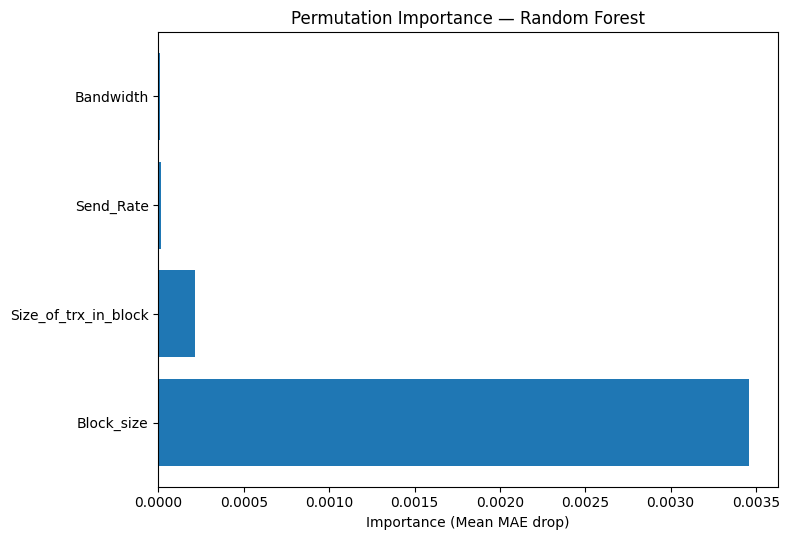

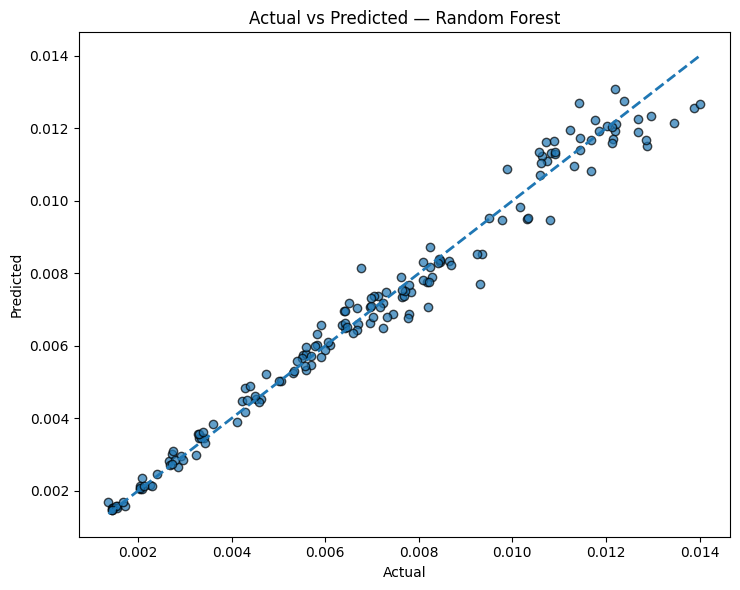

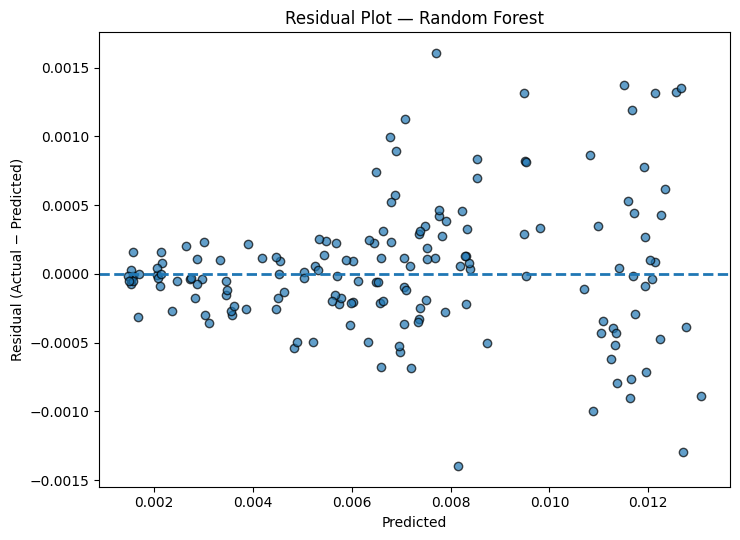

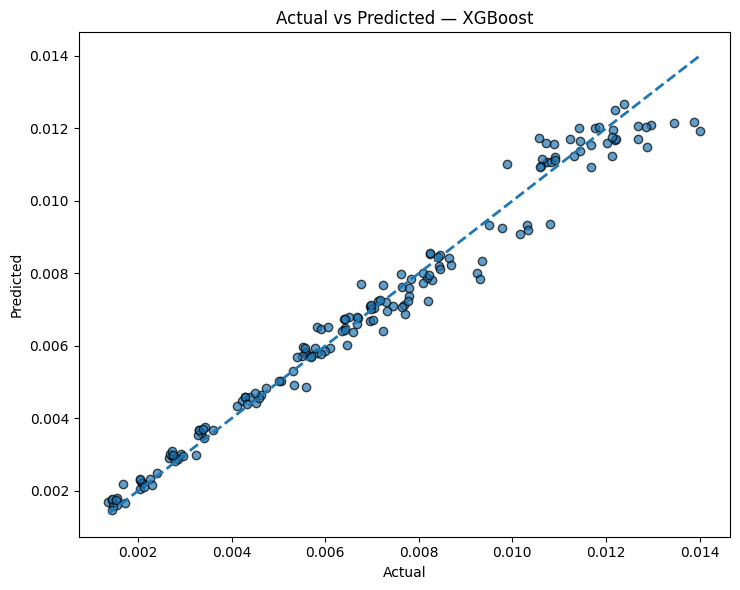

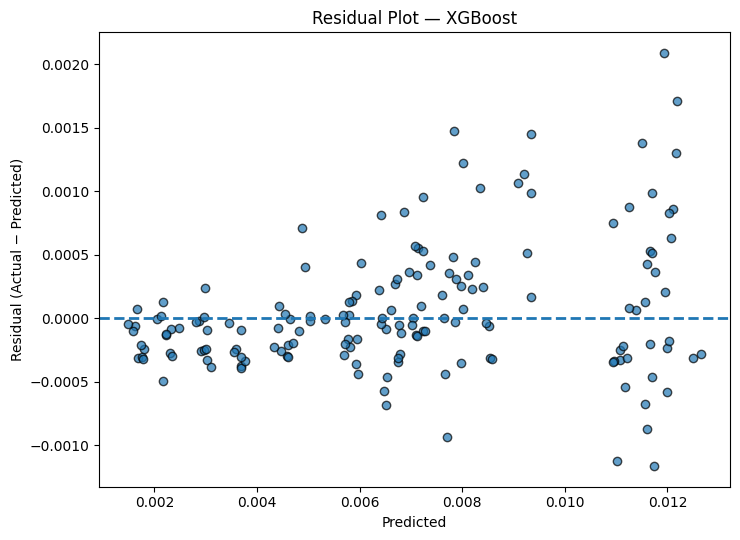

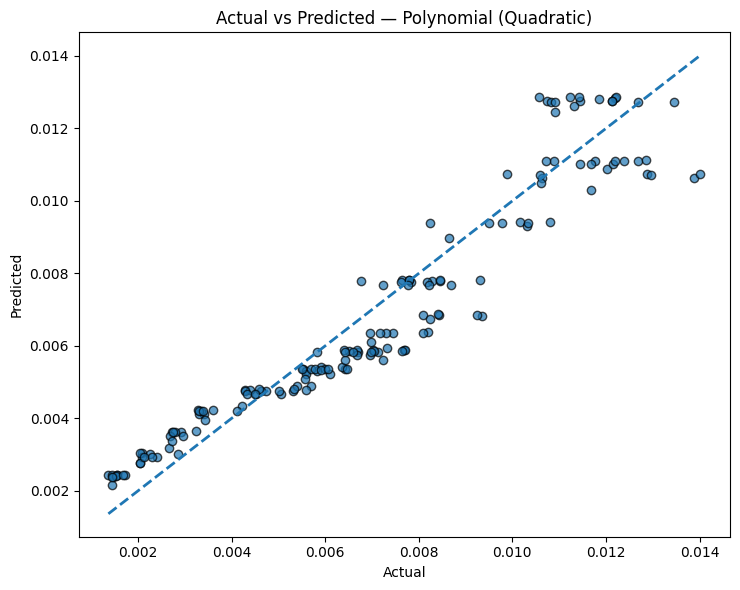

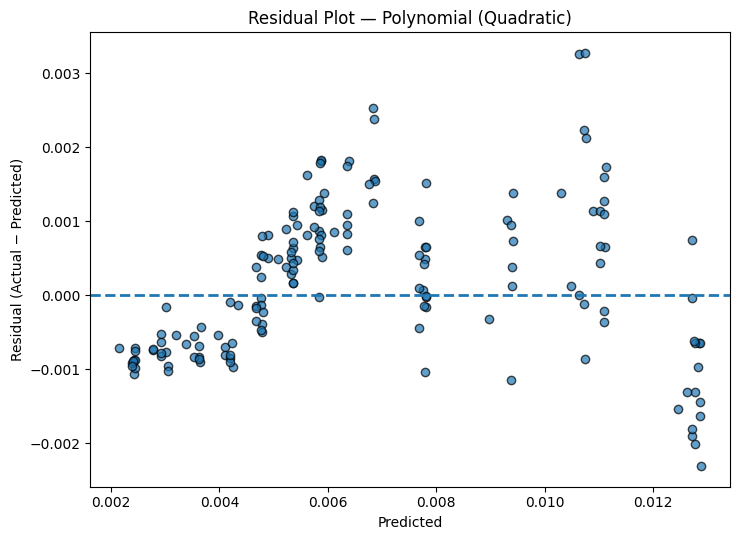

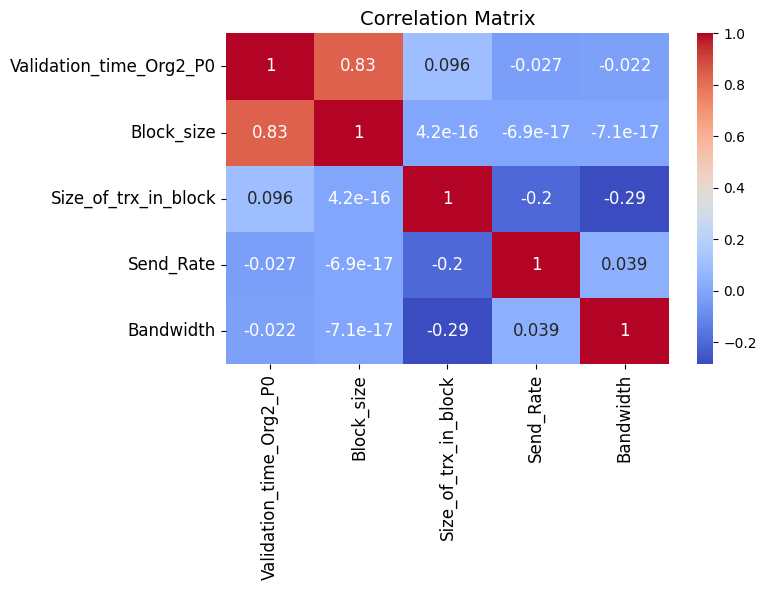

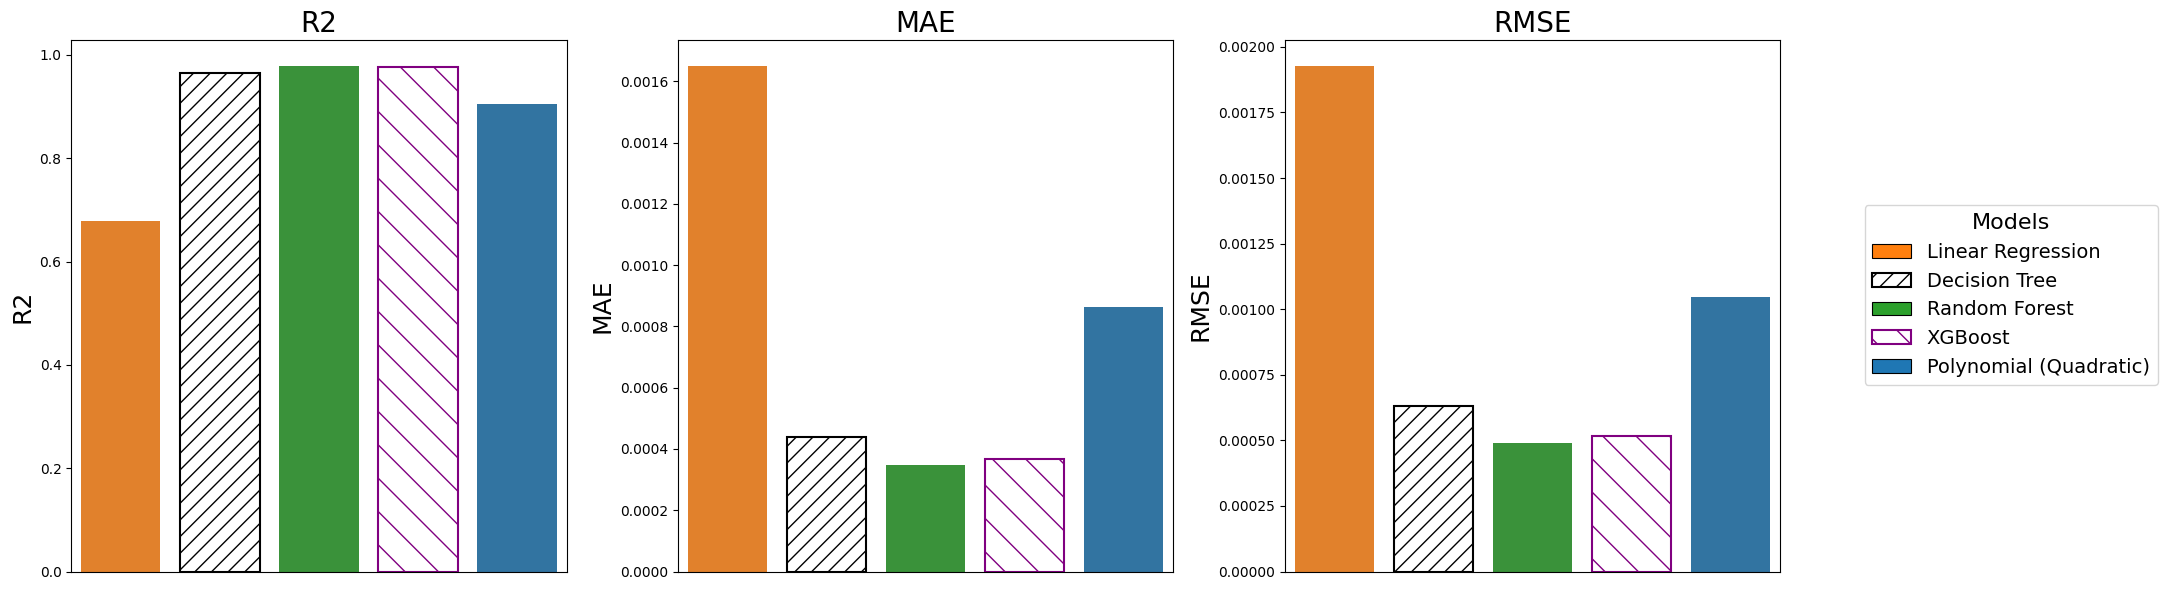

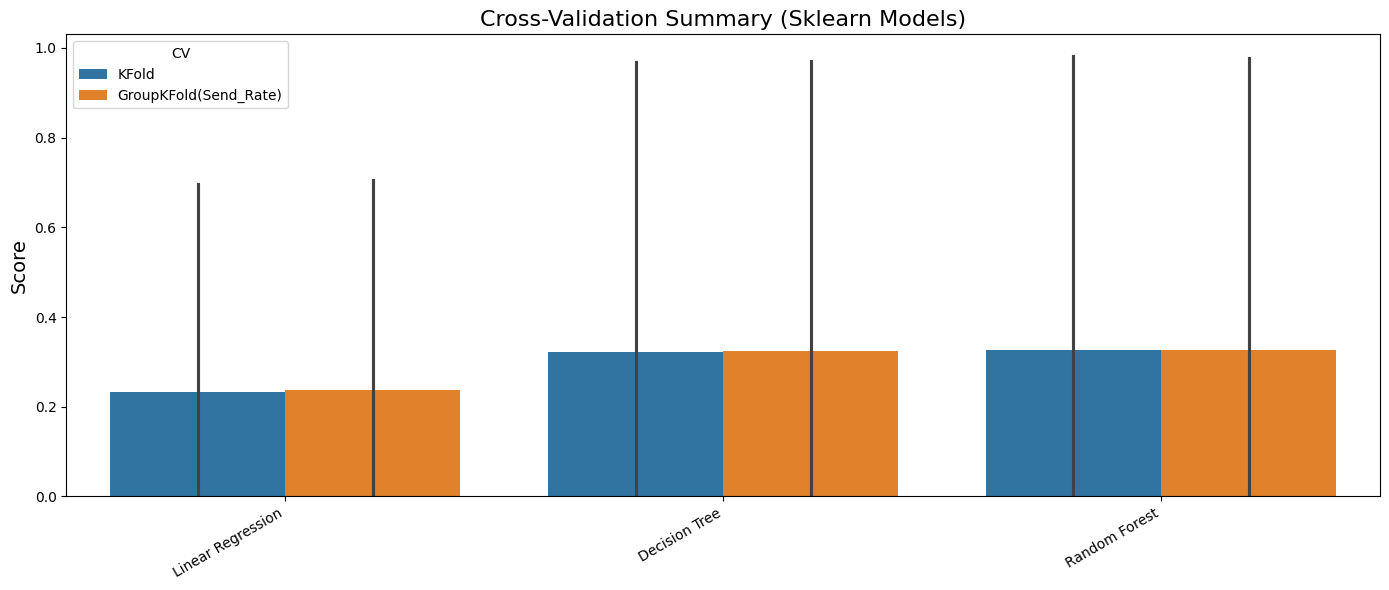


Saved models and quadratic artifacts successfully.


In [4]:
 #all model for peer0-Org1 validation time v2  


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=14,
        title='Models',
        title_fontsize=16
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Validation_time_Org2_P0'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance 
# Pick best model by lowest RMSE on the test set
best_model_name = min(test_results.keys(), key=lambda m: test_results[m]["RMSE"])

# Only sklearn models are in `models` (Quadratic isn't), so handle that case
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None  # Quadratic

print("\nBest model (by Test RMSE):", best_model_name, test_results[best_model_name])

perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAPE": test_results[m]["MAPE(%)"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors (keep your original palette idea)
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),
    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "R2", "MAE", "RMSE"]],
    metric_names=[ "R2","MAE", "RMSE"],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)



# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "VP0Org2_linear_model.pkl")
joblib.dump(models["Decision Tree"], "VP0Org2_tree_model.pkl")
joblib.dump(models["Random Forest"], "VP0Org2_forest_model.pkl")
joblib.dump(models["XGBoost"], "VP0Org2_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "VP0Org2_quadratic_params.pkl")
joblib.dump(scaler_quad, "VP0Org2_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")

